In [3]:
import autoslo.utils.paths as pu
import os
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
runs_df = pu.RunLocator.get_runs_df()
runs_df[runs_df['workload_name'] == 'tpcds_99templates_00pctheavy_120meaninterarrivals']

,run_id,workload_name,num_queries,scale_factor,schema_name,blueprint_name,query_router_name,maxconns,closed_loop
21,1763240500,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,single_4,RFixed(fixed_cluster_name='cluster_4'),1000,False
22,1763240506,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,False
23,1763240707,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
75,1763915879,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,single_32,RFixed(fixed_cluster_name='cluster_32'),1000,False
93,1765350726,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
117,1770061504,tpcds_99templates_00pctheavy_120meaninterarrivals,34,1000,ext_tpcds1000,multi_4_8,RSeqNum(selector_run_id='1770058121'),400,False


In [40]:
runs = {
    'run_4': '1763240500',
    'run_8': '1763240707',
    'run_mixed': '1770061504'
}

colors = {
    'run_4': 'blue',
    'run_8': 'green',
    'run_mixed': 'red'
}

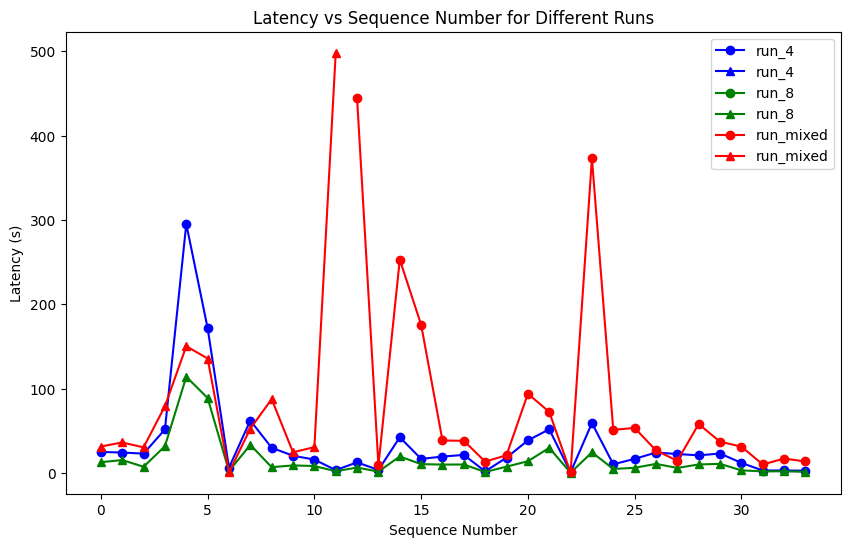

In [ ]:
from autoslo.workload_execution.trace import Trace
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(figsize=(10, 6))


for i, (run_label, run_id) in enumerate(runs.items()):
    trace = Trace(run_id)

    seq_nums = trace.seq_nums
    latencies = trace.latencies_s

    df = pd.DataFrame({
        'seq_num': seq_nums,
        'latency_s': latencies,
    })
    s = pd.Series(df.index).apply(lambda x: x.split('_')[1])

    df = df.merge(s.rename('rpu'), left_on='seq_num', right_index=True)
    df.sort_values('seq_num', inplace=True)

    ax.plot(df[df['rpu'] == '4']['seq_num'], df[df['rpu'] == '4']['latency_s'], label=run_label, marker='o', color=colors[run_label])
    ax.plot(df[df['rpu'] == '8']['seq_num'], df[df['rpu'] == '8']['latency_s'], label=run_label, marker='^', color=colors[run_label])

ax.set_xlabel("Sequence Number")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency vs Sequence Number for Different Runs")
ax.legend()
plt.show()




In [35]:
df

,seq_num,latency_s,query_id
query_id,,,
cluster_4_10078763#85f879ed-e27d-48df-92ca-641938ddbf40,0,31.435012,8
cluster_4_10078818#85f879ed-e27d-48df-92ca-641938ddbf40,1,36.261749,8
cluster_4_10078889#85f879ed-e27d-48df-92ca-641938ddbf40,2,30.422800,8
cluster_4_10078935#85f879ed-e27d-48df-92ca-641938ddbf40,3,79.246446,8
cluster_8_16451908#85f879ed-e27d-48df-92ca-641938ddbf40,4,150.311760,8
cluster_8_16451916#85f879ed-e27d-48df-92ca-641938ddbf40,5,135.749417,8
cluster_4_10079033#85f879ed-e27d-48df-92ca-641938ddbf40,6,0.635547,8
cluster_8_16451921#85f879ed-e27d-48df-92ca-641938ddbf40,7,52.708540,8
cluster_8_16451937#85f879ed-e27d-48df-92ca-641938ddbf40,8,87.600398,8
